# Comparison between the different altimetric product
- surface + 15m depth
- $\Delta T$<3h
- Gradient compute from the duacs speed


In [2]:
import numpy as np
import pandas as pd
import xarray as xr

import matplotlib.pyplot as plt

import os
from glob import glob

from cstes import swot_dir, drifters_dir, get_proj, lonlat2xy, zarr_dir, surface_drifters, depth_drifters, depth_100, depth_50, images_dir, U2, err_acc
from diagnosis import update_dict, dataset_coloc_combs, dataset_coloc_combs, prepared_drifters, prepared_wd, prepared_alti, compute_mean_square, compute_mean_square_groupby

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.geodesic as cgeo
crs = ccrs.PlateCarree()

import cartopy.geodesic as geod
import cartopy.crs as ccrs
import cartopy.feature as cfeature

import pyproj
from pyproj import Geod

from rasterio.transform import Affine

import pynsitu as pyn

from diagnosis import synthetic_figure
from cstes import U2, c0

# Generate

In [4]:
dt = 3

In [12]:
# SURFACE
base_dic = dict(dt='12h', 
        drifter_preprocess = '',
        drifter_preprocess_param='',
        alti_product_key='swot250m',
        alti_diff_method = 'fromduacsv',
        alti_diff_method_param = '',
        ggd_var = 'fromduacsv',
        wd_product_key = 'era5', 
        wd_model ='rio', 
        wd_depth = '0')


comb_list = [ 
    update_dict(base_dic, {'alti_diff_method':'xarray_diff', 'ggd_var':'etac'}),
    update_dict(base_dic, {'alti_diff_method':'xarray_diff', 'ggd_var':'etaf'}), 
    update_dict(base_dic, {'alti_diff_method':'diff_only', 'ggd_var':'etac'}),
    update_dict(base_dic, {'alti_diff_method':'diff_only', 'ggd_var':'etaf'}), 
    base_dic, 
    update_dict(base_dic, {'alti_product_key':'swot2km','alti_diff_method':'xarray_diff', 'ggd_var':'etac'}),
    update_dict(base_dic, {'alti_product_key':'swot2km','alti_diff_method':'xarray_diff', 'ggd_var':'etaf'}),
    update_dict(base_dic, {'alti_product_key':'swot2km','alti_diff_method':'diff_only', 'ggd_var':'etac'}),
    update_dict(base_dic, {'alti_product_key':'swot2km','alti_diff_method':'diff_only', 'ggd_var':'etaf'}),
    update_dict(base_dic, {'alti_product_key':'swot2km'}), 
    update_dict(base_dic, {'alti_product_key':'L4_noswot_regional'}),
    update_dict(base_dic, {'alti_product_key':'L4_noswot_global'}),
    update_dict(base_dic, {'alti_product_key':'L4_withnadirswot'}),
]

l = [
    'L3-250m-xr-etac',
    'L3-250m-xr-etaf',
    'L3-250m-stencil-etac',
    'L3-250m-stencil-etaf',
    'L3-250m-duacsv',
    'L3-2km-xr-etac',
    'L3-2km-xr-etaf',
    'L3-2km-stencil-etac',
    'L3-2km-stencil-etaf',
    'L3-2km-duacsv',
    'L4-no-SWOT-regional-duacsv',
    'L4-no-SWOT-global-duacsv',
    'L4-SWOT-nadir-duacsv']


ds0 = dataset_coloc_combs(comb_list, nearest =False, remove_id_outliers = True)
ds0['comb'] = ds0['id_comb']
ds0['id_comb'] = ('id_comb',l)
distance_to_coast = ds0.distance_to_coast.isel(id_comb = 0)
ds0['distance_to_coast'] = ('row_number', distance_to_coast.values)

#DEPTH 15M
base_dic = dict(dt='12h', 
            drifter_preprocess = '',
            drifter_preprocess_param='',
            alti_product_key='swot250m',
            alti_diff_method = 'fromduacsv',
            alti_diff_method_param = '',
            ggd_var = 'fromduacsv',
            wd_product_key = 'era5', 
            wd_model ='rio', 
            wd_depth = '15')
comb_list = [ 
    update_dict(base_dic, {'alti_diff_method':'xarray_diff', 'ggd_var':'etac'}),
    update_dict(base_dic, {'alti_diff_method':'xarray_diff', 'ggd_var':'etaf'}), 
    update_dict(base_dic, {'alti_diff_method':'diff_only', 'ggd_var':'etac'}),
    update_dict(base_dic, {'alti_diff_method':'diff_only', 'ggd_var':'etaf'}), 
    base_dic, 
    update_dict(base_dic, {'alti_product_key':'swot2km','alti_diff_method':'xarray_diff', 'ggd_var':'etac'}),
    update_dict(base_dic, {'alti_product_key':'swot2km','alti_diff_method':'xarray_diff', 'ggd_var':'etaf'}), 
    update_dict(base_dic, {'alti_product_key':'swot2km','alti_diff_method':'diff_only', 'ggd_var':'etac'}),
    update_dict(base_dic, {'alti_product_key':'swot2km','alti_diff_method':'diff_only', 'ggd_var':'etaf'}), 
    update_dict(base_dic, {'alti_product_key':'swot2km'}), 
    update_dict(base_dic, {'alti_product_key':'L4_noswot_regional'}),
    update_dict(base_dic, {'alti_product_key':'L4_noswot_global'}),
    update_dict(base_dic, {'alti_product_key':'L4_withnadirswot'}),
]

ds15 = dataset_coloc_combs(comb_list, nearest =False, remove_id_outliers = True)
ds15['comb'] = ds15['id_comb']
ds15['id_comb'] = ('id_comb',l)
distance_to_coast = ds15.distance_to_coast.isel(id_comb = 0)
ds15['distance_to_coast'] = ('row_number', distance_to_coast.values)

DS = xr.concat([ds0.where(ds0.depth==0, drop=True), ds15.where(ds15.depth==15, drop=True)], dim='row_number')
DS = DS.where(DS.time_to_swot/pd.Timedelta('1h')<dt).dropna('row_number')
DS = DS.where((DS.ggde<1.5e-4) & (DS.ggdn<1.5e-4), drop=True)
DS = DS.where(DS.distance_to_coast>10e3, drop=True)

# Closure figs
ds = compute_mean_square(DS)/U2
df = ds.to_dataframe()
df = df.reset_index().rename(columns={'id_comb':'Altimetric product'}).set_index('Altimetric product')


358076
12h_spectral_decomp_all_med_variational_10min_v0____swot250m_xarray_diff__etac__era5_rio0
357404
12h_spectral_decomp_all_med_variational_10min_v0____swot250m_xarray_diff__etaf__era5_rio0
358076
12h_spectral_decomp_all_med_variational_10min_v0____swot250m_diff_only__etac__era5_rio0
357404
12h_spectral_decomp_all_med_variational_10min_v0____swot250m_diff_only__etaf__era5_rio0
349647
12h_spectral_decomp_all_med_variational_10min_v0____swot250m_fromduacsv__fromduacsv__era5_rio0
303001
12h_spectral_decomp_all_med_variational_10min_v0____swot2km_xarray_diff__etac__era5_rio0
300939
12h_spectral_decomp_all_med_variational_10min_v0____swot2km_xarray_diff__etaf__era5_rio0
303001
12h_spectral_decomp_all_med_variational_10min_v0____swot2km_diff_only__etac__era5_rio0
300813
12h_spectral_decomp_all_med_variational_10min_v0____swot2km_diff_only__etaf__era5_rio0
307771
12h_spectral_decomp_all_med_variational_10min_v0____swot2km_fromduacsv__fromduacsv__era5_rio0
only 'fromduacsv' method is avail

In [11]:
DS = xr.concat([ds0.where(ds0.depth==0, drop=True), ds15.where(ds15.depth==15, drop=True)], dim='row_number')
DS = DS.where(DS.time_to_swot/pd.Timedelta('1h')<dt).dropna('row_number')
#DS = DS.where((abs(DS.ggde)<1.5e-5) & (abs(DS.ggdn)<1.5e-5), drop=True)
DS = DS.where(DS.distance_to_coast>10e3, drop=True)

# Closure figs
ds = compute_mean_square(DS)/U2
df = ds.to_dataframe()
df = df.reset_index().rename(columns={'id_comb':'Altimetric product'}).set_index('Altimetric product')


# Closure figs
print(DSS.sizes['row_number'])
for c in df.index :
    plt.rcParams["axes.edgecolor"] = "w"
    fig, axs = plt.subplots(nrows=1,ncols=2,figsize=(20,5), frameon=False)
    synthetic_figure(df.loc[c], axs[0], dir='e', xlim=[-1, 10])
    synthetic_figure(df.loc[c], axs[1], dir='n', xlim=[-1, 10])
    fig.suptitle(c)
    fig.tight_layout()
    fig.savefig(os.path.join(images_dir, 'closure_figs', '15m_' + c + '.png'))


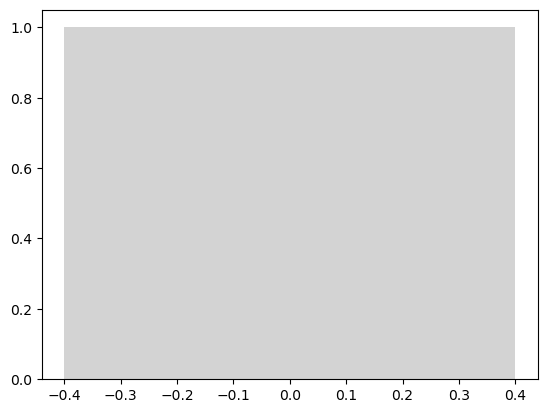

In [13]:
fig, ax=plt.subplots()
#ax.bar(0,1, color=c0['acc'], label='Lagrangian acceleration')
#ax.bar(0,1, color=c0['cor'], label='Coriolis acceleration')
ax.bar(0,1, color=c0['ggd'], label='Balanced signal contribution')
#ax.bar(0,1, color=c0['wd'], label='Wind term')
ax.bar(0,1, color='lightgrey', label='Residual contribution')

handles, labels = ax.get_legend_handles_labels()


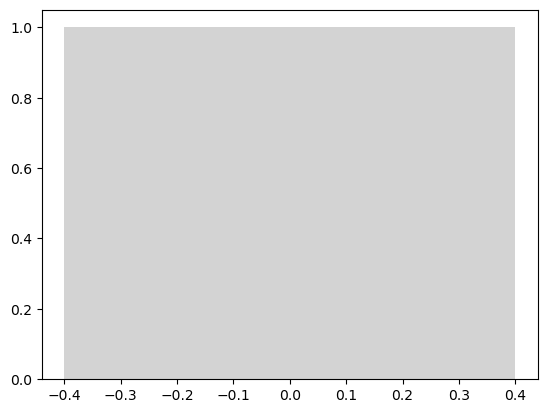

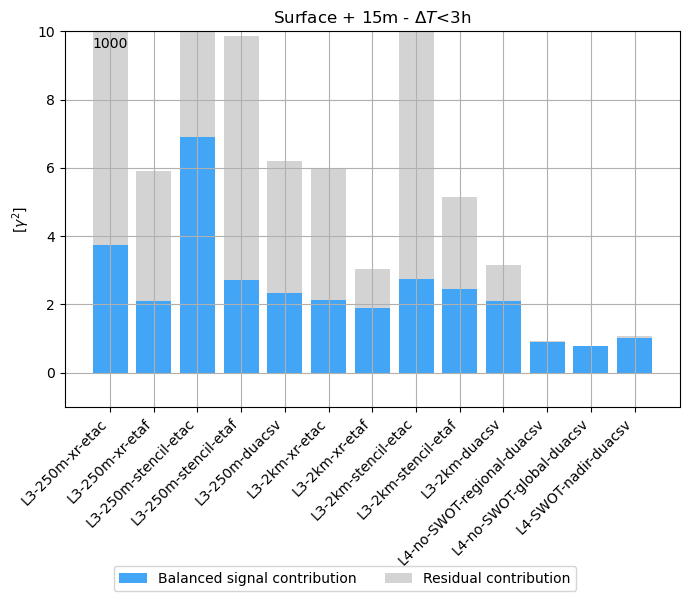

In [14]:
fig, ax=plt.subplots()
#ax.bar(0,1, color=c0['acc'], label='Lagrangian acceleration')
#ax.bar(0,1, color=c0['cor'], label='Coriolis acceleration')
ax.bar(0,1, color=c0['ggd'], label='Balanced signal contribution')
#ax.bar(0,1, color=c0['wd'], label='Wind term')
ax.bar(0,1, color='lightgrey', label='Residual contribution')

handles, labels = ax.get_legend_handles_labels()


# Alti comparison
fig, ax = plt.subplots(frameon=False, figsize=(7, 6))
plt.rcParams["axes.edgecolor"] = "k"
for i in range(len(df)):
    df_ = df.iloc[i]
    # residual contribution
    plt.rcParams["hatch.linewidth"] = 6
    if df_.E_ggd>0: ax.bar(i, df_.E_ggd, bottom = df_.B_ggd,color = 'lightgrey')
    else: ax.bar(i, df_.E_ggd,color = 'lightgrey')
    ax.bar(i, df_.B_ggd,color = c0['ggd'])

    #plt.rcParams["hatch.color"] = c0['ggd']
    #ax.bar(i, df_.X_acc_ggd/2, color = c0['acc'], hatch="/", width=0.4, label = '')
    #ax.bar(i, df_.X_cor_ggd/2, color = c0['cor'], hatch="/", width=0.4)
    #ax.bar(i, df_.X_ggd_wd/2, color = c0['wd'], hatch="/", bottom = df_.X_cor_ggd/2, width=0.4)
    
ax.grid()
ax.set_ylabel(r'[$\gamma^2$]')
ax.set_xticks(ticks = np.arange(len(df)),labels = df.index, rotation = 45, ha='right' )
ax.set_title(rf'Surface + 15m - $\Delta T$<{dt}h')
ax.set_ylim(-1,10)
ax.annotate(f'{round(df.iloc[0].E_ggd+df.iloc[0].B_ggd)}', (0,9.5), ha='center')
fig.tight_layout(rect=[0, 0.02, 1, 1])
fig.legend(handles, labels, ncol=3, loc="lower center")
#fig.savefig(os.path.join(images_dir, 'alti_comparison', 'alti_comparison_surface_ggd.png'))


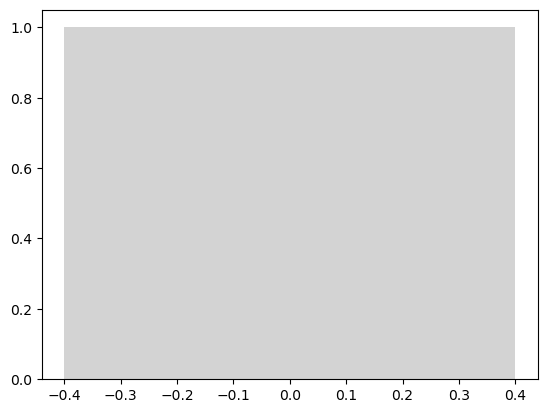

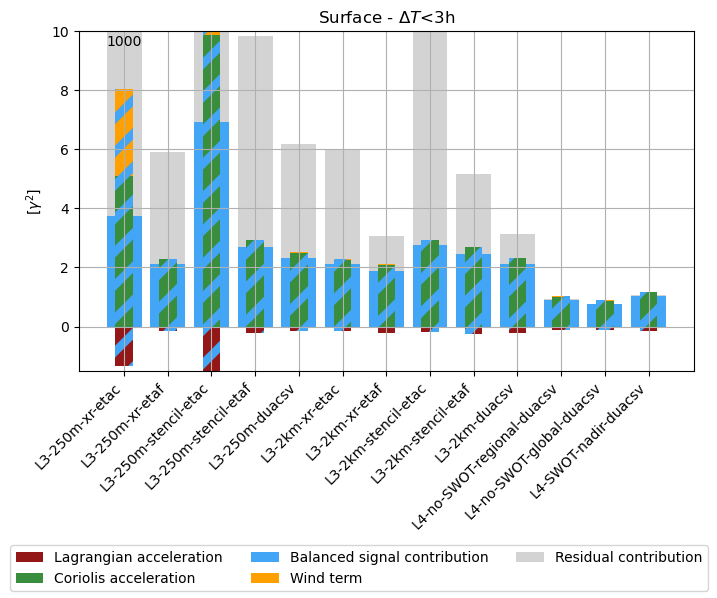

In [17]:
fig, ax=plt.subplots()
ax.bar(0,1, color=c0['acc'], label='Lagrangian acceleration')
ax.bar(0,1, color=c0['cor'], label='Coriolis acceleration')
ax.bar(0,1, color=c0['ggd'], label='Balanced signal contribution')
ax.bar(0,1, color=c0['wd'], label='Wind term')
ax.bar(0,1, color='lightgrey', label='Residual contribution')

handles, labels = ax.get_legend_handles_labels()


# Alti comparison
fig, ax = plt.subplots(frameon=False, figsize=(7, 6))
plt.rcParams["axes.edgecolor"] = "k"
for i in range(len(df)):
    df_ = df.iloc[i]
    # residual contribution
    plt.rcParams["hatch.linewidth"] = 6
    if df_.E_ggd>0: ax.bar(i, df_.E_ggd, bottom = df_.B_ggd,color = 'lightgrey')
    else: ax.bar(i, df_.E_ggd,color = 'lightgrey')
    ax.bar(i, df_.B_ggd,color = c0['ggd'])

    plt.rcParams["hatch.color"] = c0['ggd']
    ax.bar(i, df_.X_acc_ggd/2, color = c0['acc'], hatch="/", width=0.4, label = '')
    ax.bar(i, df_.X_cor_ggd/2, color = c0['cor'], hatch="/", width=0.4)
    ax.bar(i, df_.X_ggd_wd/2, color = c0['wd'], hatch="/", bottom = df_.X_cor_ggd/2, width=0.4)
    
ax.grid()
ax.set_ylabel(r'[$\gamma^2$]')
ax.set_xticks(ticks = np.arange(len(df)),labels = df.index, rotation = 45,ha='right' )
ax.set_title(rf'Surface - $\Delta T$<{dt}h')
ax.set_ylim(-1.5,10)
ax.annotate(f'{round(df.iloc[0].E_ggd+df.iloc[0].B_ggd)}', (0,9.5), ha='center')
fig.tight_layout(rect=[0, 0.08, 1, 1])
fig.legend(handles, labels, ncol=3, loc="lower center")
#fig.savefig(os.path.join(images_dir, 'alti_comparison', 'alti_comparison_surface_ggd.png'))


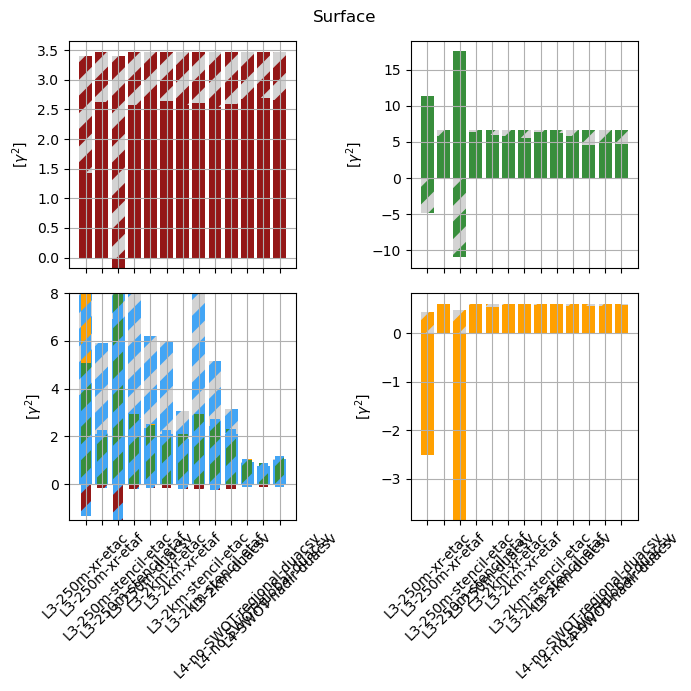

In [18]:
# Alti comparison
vars = ['acc', 'cor', 'ggd','wd']
plt.rcParams["axes.edgecolor"] = "k"
fig, axs = plt.subplots(2, 2, figsize = (7, 7), frameon=False, sharex=True)
axs = axs.flatten()
for i in range(len(df)):
    df_ = df.iloc[i]
    plt.rcParams["hatch.linewidth"] = 8
    for j in range(4):
        ax=axs[j]
        # residual contribution
        plt.rcParams["hatch.color"] = "lightgrey"
        if df_['E_'+vars[j]]>0: ax.bar(i, df_['E_'+vars[j]], bottom = df_['B_'+vars[j]],color = c0[vars[j]], hatch="/")
        else: ax.bar(i, df_['E_'+vars[j]], color = c0[vars[j]], hatch="/")
        ax.bar(i, df_['B_'+vars[j]],color = c0[vars[j]])


    ax = axs[2]
    plt.rcParams["hatch.color"] = c0['ggd']
    ax.bar(i, df_.X_acc_ggd/2, color = c0['acc'], hatch="/", width=0.6)
    ax.bar(i, df_.X_cor_ggd/2, color = c0['cor'], hatch="/", width=0.6)
    ax.bar(i, df_.X_ggd_wd/2, color = c0['wd'], hatch="/", bottom = df_.X_cor_ggd/2, width=0.6)

for ax in axs :    
    ax.grid()
    ax.set_ylabel(r'[$\gamma^2$]')
    ax.set_xticks(ticks = np.arange(len(df)),labels = df.index, rotation = 45 )

axs[2].set_ylim(-1.5,8)
fig.suptitle('Surface')
fig.tight_layout()
#fig.savefig(os.path.join(images_dir, 'alti_comparison', 'alti_comparison_surface_all.png'))
